In [1]:
path = "/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/src/multi_scale_cellpose/split_cell_refinement_cache/mask_coords_cache.pkl"
import pickle
with open(path, "rb") as f:
    mask_coords_cache = pickle.load(f)



In [6]:
mask_coords_cache['/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output/tmp/T12NS_T5577-2_slideA2A/T12NS_T5577-2_slideA2A_diameter_29.tif'][0][1]

array([[ 627,  627,  627, ...,  666,  666,  666],
       [1845, 1846, 1847, ..., 1848, 1849, 1850]])

In [8]:
mask_path = "/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output/splitted_mask.tif"
import tifffile
mask = tifffile.imread(mask_path)

from skimage.measure import regionprops, label
import numpy as np
print(len(np.unique(mask)))
props = regionprops(mask)
for prop in props:
    minr, minc, maxr, maxc = prop.bbox
    if maxr - minr > 1000 or maxc - minc > 1000:
        print(prop.label)
        new_mask = np.zeros((maxr - minr, maxc - minc), dtype=np.uint8)
        new_mask[mask[minr:maxr, minc:maxc] == prop.label] = 1
        import matplotlib.pyplot as plt
        plt.imshow(new_mask)
        plt.show()
        break



70511


In [2]:
path = "/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/src/multi_scale_cellpose/split_cell_refinement_cache/coords_per_label.pkl"

import pickle

with open(path, "rb") as f:
    coords_per_label = pickle.load(f)



In [4]:
coords_per_label

{np.uint32(46840): array([[ 616,  617,  617, ...,  668,  668,  668],
        [1851, 1847, 1848, ..., 1849, 1850, 1851]]),
 np.uint32(53492): array([[ 632,  632,  632,  632,  633,  633,  633,  633,  633,  633,  633,
          634,  634,  634,  634,  634,  634,  634,  634,  634,  635,  635,
          635,  635,  635,  635,  635,  635,  635,  635,  636,  636,  636,
          636,  636,  636,  636,  636,  636,  636,  636,  636,  637,  637,
          637,  637,  637,  637,  637,  637,  637,  637,  637,  637,  637,
          638,  638,  638,  638,  638,  638,  638,  638,  638,  638,  638,
          638,  638,  639,  639,  639,  639,  639,  639,  639,  639,  639,
          639,  639,  639,  639,  640,  640,  640,  640,  640,  640,  640,
          640,  640,  640,  640,  640,  640,  641,  641,  641,  641,  641,
          641,  641,  641,  641,  641,  641,  641,  641,  642,  642,  642,
          642,  642,  642,  642,  642,  642,  642,  642,  642,  642,  643,
          643,  643,  643,  643,  6

In [ ]:
for label, coords in coords_per_label.items():
    minr = np.min(coords[0])
    maxr = np.max(coords[0])
    minc = np.min(coords[1])
    maxc = np.max(coords[1])
    if maxr - minr > 1000 or maxc - minc > 1000:
        print(label)
        new_mask = np.zeros((maxr - minr+1, maxc - minc+1), dtype=np.uint8)
        new_mask[coords[0] - minr, coords[1] - minc] = 1
        import matplotlib.pyplot as plt
        plt.imshow(new_mask)
        plt.show()
    # break

array([ 0,  0,  0, ..., 66, 66, 66])

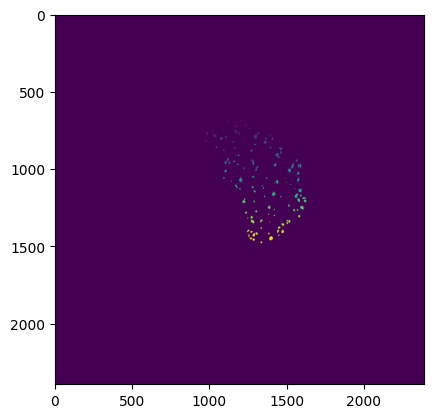

In [2]:
path = "/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output/tmp/37 Slide 1 Section B3 DAPI/37 Slide 1 Section B3 DAPI_diameter_11.tif"
from skimage.io import imread
image_array = imread(path)
image_array.shape

import matplotlib.pyplot as plt
plt.imshow(image_array)
plt.show()

In [ ]:
import cellpose

print(cellpose.__version__)